In [1]:
import pandas as pd
import data_profiling
import numpy as np
from data_profiling import ProfileReport

In [4]:
df = pd.read_csv('../data/raw//train.csv')

In [4]:
profile = ProfileReport(df, title="Profiling Report", explorative=True)
profile.to_file('report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:11<00:00,  1.28it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [5]:
df.shape

(690088, 15)

In [6]:
df.dtypes

id                           int64
health_condition            object
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                   object
stress_level                object
sleep_quality               object
physical_activity_level     object
smoking_alcohol             object
gender                      object
dtype: object

In [7]:
df.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [8]:
df.head(10)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
5,5,at-risk,5.11,82.8,24.43,2290.0,2134.0,29.2,2.02,veg,low,poor,sedentary,occasional,male
6,6,at-risk,8.21,71.1,24.14,2723.0,12984.0,54.5,2.01,balanced,low,NaN,moderate,no,female
7,7,at-risk,7.47,87.0,23.51,NaN,3096.0,37.5,0.51,balanced,low,average,sedentary,occasional,male
8,8,unhealthy,5.94,75.4,24.36,NaN,12165.0,61.6,1.56,veg,high,average,active,no,other
9,9,at-risk,6.97,80.1,20.47,2928.0,13108.0,51.9,2.53,veg,medium,good,active,no,male


In [9]:
missing = df.isnull().mean()*100
print(missing[missing>0].sort_values(ascending=False))

stress_level               12.000064
sleep_duration             11.012943
sleep_quality               8.452690
calorie_expenditure         7.658878
water_intake                6.300211
physical_activity_level     5.306715
smoking_alcohol             4.141791
gender                      3.097141
step_count                  2.016554
bmi                         2.013946
heart_rate                  1.135073
diet_type                   1.000017
exercise_duration           1.000017
dtype: float64


In [10]:
n_dupes = df.duplicated().sum()
n_dupes

np.int64(0)

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['health_condition'] = le.fit_transform(df['health_condition'])

In [12]:
print(le.classes_)

['at-risk' 'fit' 'unhealthy']


In [13]:
df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,0,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,0,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [14]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
numeric_df = numeric_df.drop(columns=['id'])

corr_matrix = numeric_df.corr()

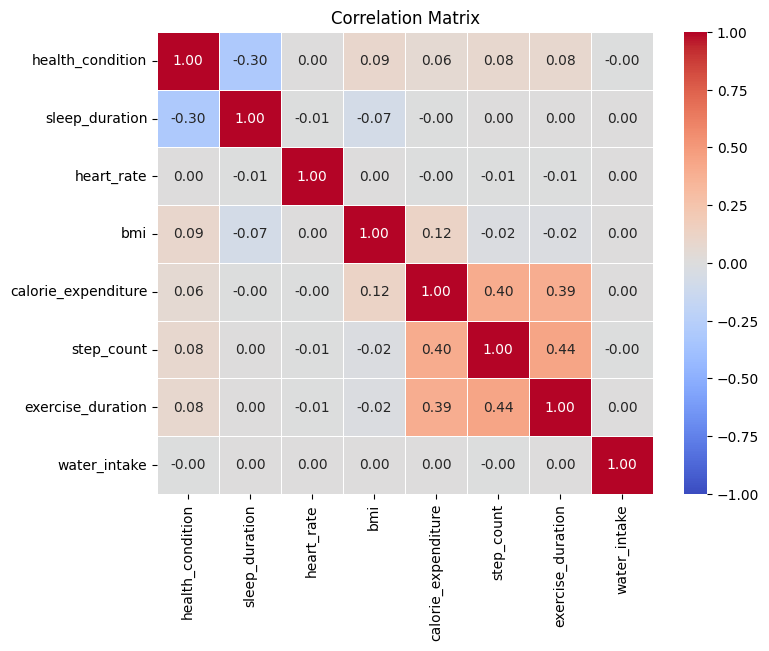

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidth=0.5,
    vmin=-1, vmax=1
)
plt.title('Correlation Matrix')
plt.show()

In [16]:
df.dtypes

id                           int64
health_condition             int64
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                   object
stress_level                object
sleep_quality               object
physical_activity_level     object
smoking_alcohol             object
gender                      object
dtype: object

In [17]:
df['diet_type'].isnull().sum()

np.int64(6901)

In [18]:
df['diet_type'].value_counts()

diet_type
veg         231432
balanced    226888
non-veg     224867
Name: count, dtype: int64

In [19]:
df.dropna(subset=['diet_type'], inplace=True)

In [20]:
df['diet_type'].isnull().sum()

np.int64(0)

In [21]:
df = pd.get_dummies(df, columns=['diet_type'], drop_first=True, dtype=int)

In [22]:
df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,diet_type_non-veg,diet_type_veg
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,high,average,sedentary,yes,female,0,1
1,1,0,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,low,average,moderate,yes,other,1,0
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,high,poor,active,yes,male,0,1
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,high,average,active,occasional,female,0,1
4,4,0,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,NaN,average,sedentary,NaN,male,0,1


In [23]:
df['stress_level'].value_counts()

stress_level
medium    259141
high      175982
low       166022
Name: count, dtype: int64

In [24]:
df['stress_level'].isnull().sum()

np.int64(82042)

In [25]:
df['stress_level'] = df.groupby('health_condition')['stress_level'].transform(
    lambda x: x.fillna(x.mode()[0])
)

In [26]:
df['stress_level'].isnull().sum()

np.int64(0)

In [27]:
stress_mapping = {'low': 0, 'medium': 1, 'high': 2}
df['stress_level'] = df['stress_level'].map(stress_mapping)

In [28]:
df['stress_level'].value_counts()

stress_level
1    329590
2    182846
0    170751
Name: count, dtype: int64

In [29]:
df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,diet_type_non-veg,diet_type_veg
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,2,average,sedentary,yes,female,0,1
1,1,0,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,0,average,moderate,yes,other,1,0
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,2,poor,active,yes,male,0,1
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,2,average,active,occasional,female,0,1
4,4,0,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,1,average,sedentary,NaN,male,0,1


In [30]:
df.dtypes

id                           int64
health_condition             int64
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
stress_level                 int64
sleep_quality               object
physical_activity_level     object
smoking_alcohol             object
gender                      object
diet_type_non-veg            int64
diet_type_veg                int64
dtype: object

In [31]:
df['sleep_quality'].isnull().sum()

np.int64(57733)

In [32]:
df['sleep_quality'].value_counts()

sleep_quality
average    211823
poor       210020
good       203611
Name: count, dtype: int64

In [33]:
df['sleep_quality'] = df.groupby('stress_level')['sleep_quality'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'average')
)

In [34]:
sleep_mapping = {'poor': 0, 'average': 1, 'good': 2}
df['sleep_quality'] = df['sleep_quality'].map(sleep_mapping)

In [35]:
df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,diet_type_non-veg,diet_type_veg
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,2,1,sedentary,yes,female,0,1
1,1,0,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,0,1,moderate,yes,other,1,0
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,2,0,active,yes,male,0,1
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,2,1,active,occasional,female,0,1
4,4,0,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,1,1,sedentary,NaN,male,0,1


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 683187 entries, 0 to 690087
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       683187 non-null  int64  
 1   health_condition         683187 non-null  int64  
 2   sleep_duration           607983 non-null  float64
 3   heart_rate               675430 non-null  float64
 4   bmi                      669439 non-null  float64
 5   calorie_expenditure      630851 non-null  float64
 6   step_count               669414 non-null  float64
 7   exercise_duration        676358 non-null  float64
 8   water_intake             639710 non-null  float64
 9   stress_level             683187 non-null  int64  
 10  sleep_quality            683187 non-null  int64  
 11  physical_activity_level  646906 non-null  object 
 12  smoking_alcohol          654918 non-null  object 
 13  gender                   662444 non-null  object 
 14  diet_type

In [37]:
df['physical_activity_level'].value_counts()

physical_activity_level
moderate     218783
sedentary    217592
active       210531
Name: count, dtype: int64

In [38]:
df['physical_activity_level'].isnull().sum()

np.int64(36281)

In [39]:
duration_buckets = pd.qcut(df['exercise_duration'], q=4)
df['physical_activity_level'] = df.groupby(duration_buckets)['physical_activity_level'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'average')
)

C:\temp_tmp\ipykernel_26568\763626299.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['physical_activity_level'] = df.groupby(duration_buckets)['physical_activity_level'].transform(


In [40]:
df['physical_activity_level'].isna().sum()

np.int64(6829)

In [41]:
physical_mapping = {'sedentary': 0, 'moderate': 1, 'active': 2}
df['physical_activity_level'] = df['physical_activity_level'].map(physical_mapping)

In [42]:
df['physical_activity_level'].value_counts()

physical_activity_level
1.0    234427
0.0    224530
2.0    217401
Name: count, dtype: int64

In [43]:
# 1. Fill the remaining NaNs with 1 (which represents 'moderate', your most common class)
df['physical_activity_level'] = df['physical_activity_level'].fillna(1)

# 2. Force the column to drop the decimals and become integers
df['physical_activity_level'] = df['physical_activity_level'].astype(int)

# 3. Verify it worked!
df['physical_activity_level'].value_counts()

physical_activity_level
1    241256
0    224530
2    217401
Name: count, dtype: int64

In [44]:
df['physical_activity_level'].isna().sum()

np.int64(0)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 683187 entries, 0 to 690087
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       683187 non-null  int64  
 1   health_condition         683187 non-null  int64  
 2   sleep_duration           607983 non-null  float64
 3   heart_rate               675430 non-null  float64
 4   bmi                      669439 non-null  float64
 5   calorie_expenditure      630851 non-null  float64
 6   step_count               669414 non-null  float64
 7   exercise_duration        676358 non-null  float64
 8   water_intake             639710 non-null  float64
 9   stress_level             683187 non-null  int64  
 10  sleep_quality            683187 non-null  int64  
 11  physical_activity_level  683187 non-null  int64  
 12  smoking_alcohol          654918 non-null  object 
 13  gender                   662444 non-null  object 
 14  diet_type

In [46]:
df['smoking_alcohol'].isnull().sum()

np.int64(28269)

In [48]:
df['smoking_alcohol'] = df.groupby('health_condition')['smoking_alcohol'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'yes')
)

In [50]:
habit_mapping = {'no': 0, 'occasional': 1, 'yes': 2}
df['smoking_alcohol'] = df['smoking_alcohol'].map(habit_mapping)

In [51]:
df['smoking_alcohol'].isnull().sum()

np.int64(0)

In [52]:
df['smoking_alcohol'].value_counts()

smoking_alcohol
0    243475
2    223852
1    215860
Name: count, dtype: int64

In [53]:
df['gender'].isnull().sum()

np.int64(20743)

In [54]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

In [55]:
# 2. One-Hot Encode the column to turn it into 1s and 0s
# drop_first=True prevents the "dummy variable trap" (perfect multicollinearity)
# dtype=int ensures it outputs as 0s and 1s instead of True/False booleans
df = pd.get_dummies(df, columns=['gender'], drop_first=True, dtype=int)

In [57]:
df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,diet_type_non-veg,diet_type_veg,gender_male,gender_other
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,2,1,0,2,0,1,0,0
1,1,0,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,0,1,1,2,1,0,0,1
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,2,0,2,2,0,1,1,0
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,2,1,2,1,0,1,0,0
4,4,0,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,1,1,0,0,0,1,1,0


In [59]:
df.shape

(683187, 17)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 683187 entries, 0 to 690087
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       683187 non-null  int64  
 1   health_condition         683187 non-null  int64  
 2   sleep_duration           607983 non-null  float64
 3   heart_rate               675430 non-null  float64
 4   bmi                      669439 non-null  float64
 5   calorie_expenditure      630851 non-null  float64
 6   step_count               669414 non-null  float64
 7   exercise_duration        676358 non-null  float64
 8   water_intake             639710 non-null  float64
 9   stress_level             683187 non-null  int64  
 10  sleep_quality            683187 non-null  int64  
 11  physical_activity_level  683187 non-null  int64  
 12  smoking_alcohol          683187 non-null  int64  
 13  diet_type_non-veg        683187 non-null  int64  
 14  diet_type

In [61]:
df = df.drop('id', axis=1)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 683187 entries, 0 to 690087
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   health_condition         683187 non-null  int64  
 1   sleep_duration           607983 non-null  float64
 2   heart_rate               675430 non-null  float64
 3   bmi                      669439 non-null  float64
 4   calorie_expenditure      630851 non-null  float64
 5   step_count               669414 non-null  float64
 6   exercise_duration        676358 non-null  float64
 7   water_intake             639710 non-null  float64
 8   stress_level             683187 non-null  int64  
 9   sleep_quality            683187 non-null  int64  
 10  physical_activity_level  683187 non-null  int64  
 11  smoking_alcohol          683187 non-null  int64  
 12  diet_type_non-veg        683187 non-null  int64  
 13  diet_type_veg            683187 non-null  int64  
 14  gender_ma

In [63]:
df.isnull().sum()

health_condition               0
sleep_duration             75204
heart_rate                  7757
bmi                        13748
calorie_expenditure        52336
step_count                 13773
exercise_duration           6829
water_intake               43477
stress_level                   0
sleep_quality                  0
physical_activity_level        0
smoking_alcohol                0
diet_type_non-veg              0
diet_type_veg                  0
gender_male                    0
gender_other                   0
dtype: int64

In [65]:
df['sleep_duration'].isnull().sum()

np.int64(75204)

In [66]:
print(df.skew().sort_values(ascending=False))

health_condition           2.427127
gender_other               0.905752
diet_type_non-veg          0.727199
diet_type_veg              0.681393
gender_male                0.501578
water_intake               0.110229
smoking_alcohol            0.053429
bmi                        0.024476
sleep_quality              0.019242
physical_activity_level    0.018866
heart_rate                -0.000075
sleep_duration            -0.008399
stress_level              -0.026273
step_count                -0.180336
calorie_expenditure       -0.183782
exercise_duration         -0.374622
dtype: float64


In [74]:
df['sleep_duration'] = df.groupby('sleep_quality')['sleep_duration'].transform(
    lambda x: x.fillna(x.median())
)

In [75]:
df['sleep_duration'] = df['sleep_duration'].fillna(df['sleep_duration'].median())

In [76]:
df['sleep_duration'].isnull().sum()

np.int64(0)

In [77]:
df['heart_rate'].isnull().sum()

np.int64(7757)

In [79]:
# 1. Fill missing heart rates based on the median of their specific physical activity group
df['heart_rate'] = df.groupby('physical_activity_level')['heart_rate'].transform(
    lambda x: x.fillna(x.median())
)

In [80]:
df['heart_rate'].isnull().sum()

np.int64(0)

In [81]:
df['bmi'].isnull().sum()

np.int64(13748)

In [85]:
df.tail()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,diet_type_non-veg,diet_type_veg,gender_male,gender_other
690083,0,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,2,0,2,2,1,0,0,0
690084,0,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,1,1,1,0,0,1,1,0
690085,1,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,0,1,2,0,1,0,1,0
690086,0,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,1,1,2,2,0,0,1,0
690087,0,5.55,69.3,24.38,2257.0,5144.0,47.9,1.76,1,1,1,2,0,0,1,0


In [82]:
# 1. Fill missing BMI based on the median of their specific physical activity group
df['bmi'] = df.groupby('physical_activity_level')['bmi'].transform(
    lambda x: x.fillna(x.median())
)

# 2. Catch any leftover NaNs with the global median just to be 100% safe
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [83]:
df.isnull().sum()

health_condition               0
sleep_duration                 0
heart_rate                     0
bmi                            0
calorie_expenditure        52336
step_count                 13773
exercise_duration           6829
water_intake               43477
stress_level                   0
sleep_quality                  0
physical_activity_level        0
smoking_alcohol                0
diet_type_non-veg              0
diet_type_veg                  0
gender_male                    0
gender_other                   0
dtype: int64

In [ ]:
# 1. Fill missing BMI based on the median of their specific physical activity group
df['bmi'] = df.groupby('physical_activity_level')['bmi'].transform(
    lambda x: x.fillna(x.median())
)

# 2. Catch any leftover NaNs with the global median just to be 100% safe
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [86]:
# 1. Fill missing calorie expenditure based on the median of their specific physical activity group
df['calorie_expenditure'] = df.groupby('physical_activity_level')['calorie_expenditure'].transform(
    lambda x: x.fillna(x.median())
)

In [88]:
# 1. Fill missing calorie expenditure based on the median of their specific physical activity group
df['step_count'] = df.groupby('physical_activity_level')['step_count'].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:
# 1. Fill missing calorie expenditure based on the median of their specific physical activity group
df['step_count'] = df.groupby('physical_activity_level')['step_count'].transform(
    lambda x: x.fillna(x.median())
)

In [93]:
df['exercise_duration'] = df.groupby('physical_activity_level')['exercise_duration'].transform(
    lambda x: x.fillna(x.median())
)

In [94]:
df['water_intake'] = df.groupby('physical_activity_level')['water_intake'].transform(
    lambda x: x.fillna(x.median())
)

In [95]:
df.isnull().sum()

health_condition           0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
diet_type_non-veg          0
diet_type_veg              0
gender_male                0
gender_other               0
dtype: int64

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 683187 entries, 0 to 690087
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   health_condition         683187 non-null  int64  
 1   sleep_duration           683187 non-null  float64
 2   heart_rate               683187 non-null  float64
 3   bmi                      683187 non-null  float64
 4   calorie_expenditure      683187 non-null  float64
 5   step_count               683187 non-null  float64
 6   exercise_duration        683187 non-null  float64
 7   water_intake             683187 non-null  float64
 8   stress_level             683187 non-null  int64  
 9   sleep_quality            683187 non-null  int64  
 10  physical_activity_level  683187 non-null  int64  
 11  smoking_alcohol          683187 non-null  int64  
 12  diet_type_non-veg        683187 non-null  int64  
 13  diet_type_veg            683187 non-null  int64  
 14  gender_ma

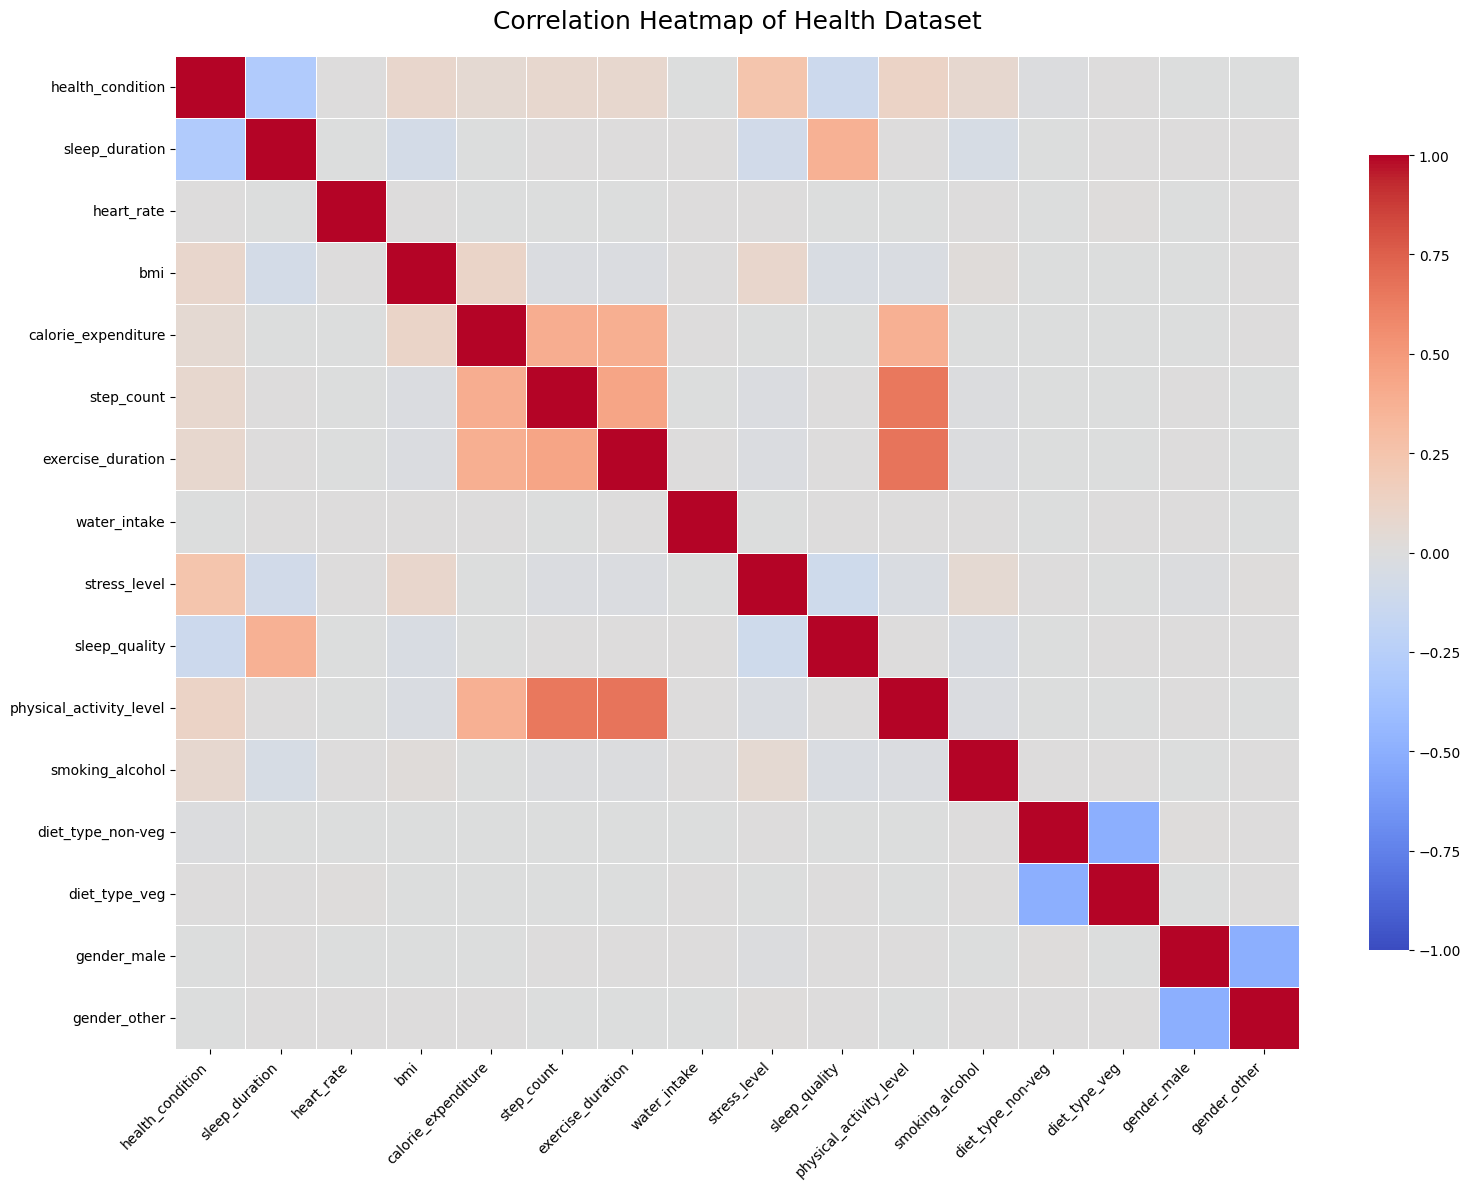

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the correlation matrix (Pearson correlation by default)
corr_matrix = df.corr()

# 2. Set up the figure size 
# We make it large (16x12) because you have many encoded columns
plt.figure(figsize=(16, 12))

# 3. Generate the heatmap
sns.heatmap(
    corr_matrix, 
    annot=False,             # Set to True only if you want to see the exact numbers (can be cluttered)
    cmap='coolwarm',         # Blue = Negative correlation, Red = Positive correlation
    linewidths=0.5,          # Adds a subtle gridline between cells for readability
    vmin=-1, vmax=1,         # Locks the color scale from -1 to 1 
    cbar_kws={"shrink": .8}  # Shrinks the color legend slightly to match the graph height
)

# 4. Format labels and display
plt.title('Correlation Heatmap of Health Dataset', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10) 
plt.yticks(fontsize=10)
plt.tight_layout()           # Ensures nothing gets cut off
plt.show()

C:\temp_tmp\ipykernel_26568\2679810381.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')


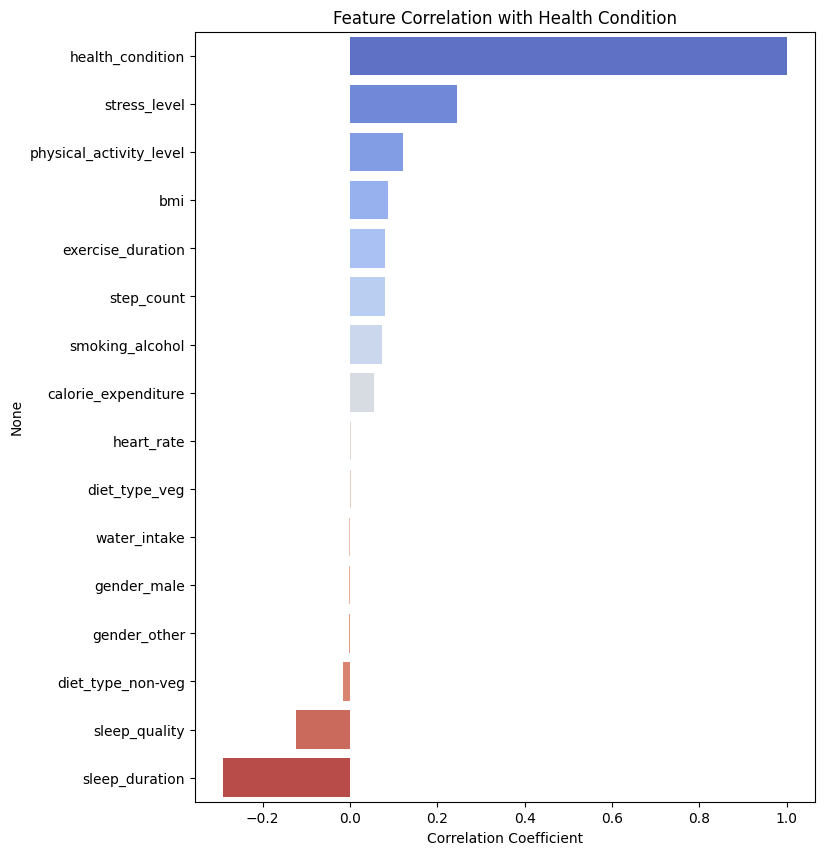

In [101]:
# Replace 'health_condition' with whatever your main target variable is
target_corr = df.corr()['health_condition'].sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')
plt.title('Feature Correlation with Health Condition')
plt.xlabel('Correlation Coefficient')
plt.show()

In [102]:
profile = ProfileReport(df, title="Processed Profiling Report", explorative=True)
profile.to_file('processed_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:00<00:00, 25.78it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]